TAHAP 1: Persiapan Lingkungan Analisis

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

**Interpretasi:**
Tahap ini menyiapkan semua library yang dibutuhkan untuk analisis clustering. Google Colab sudah memiliki sebagian besar library ini, kecuali plotly yang perlu diinstall terlebih dahulu. Library scikit-learn menyediakan fungsi K-Means, normalisasi Min-Max, dan metrik evaluasi seperti Silhouette Score serta Davies-Bouldin Index. Library plotly digunakan untuk membuat radar plot interaktif.

TAHAP 2: Load Data dari Excel

In [26]:
from google.colab import files
print("Upload file Excel: DATA MINING.xlsx")
uploaded = files.upload()

Upload file Excel: DATA MINING.xlsx


Saving DATA MINING.xlsx to DATA MINING (1).xlsx


In [27]:
import io
filename = list(uploaded.keys())[0]

# Baca file Excel, skip 2 baris pertama (karena header ganda)
df_raw = pd.read_excel(io.BytesIO(uploaded[filename]), sheet_name='FIX', skiprows=1)

print(f"Data loaded: {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom")
print("\n5 data pertama:")
df_raw.head()

Data loaded: 38 baris, 25 kolom

5 data pertama:


,Unnamed: 0,Unnamed: 1,SD,SMP,SMA,SMK,SD.1,SMP.1,SMA.1,SMK.1,...,Bersama.2,Terpisah.3,Bersama.3,SD.2,SMP.2,SMA.2,SMK.2,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,1,Aceh,37.12,45.77,47.20,51.83,81.94,80.12,86.92,90.18,...,10.13,78.57,10.71,10,9,10,7,72.36,11.53,67.76
1,2,Sumatera Utara,41.22,49.62,59.78,62.37,80.62,83.39,86.33,86.25,...,10.51,75.66,11.75,13,14,16,14,84.81,13.72,80.55
2,3,Sumatera Barat,36.67,48.89,53.68,60.13,84.36,83.93,88.41,85.65,...,7.54,81.48,10.65,12,11,14,12,90.09,20.07,86.62
3,4,Riau,45.92,50.63,66.28,66.83,83.27,83.35,86.28,91.61,...,9.15,77.74,11.94,14,12,14,12,86.14,14.17,81.16
4,5,Jambi,36.20,44.11,55.33,50.88,83.59,82.36,88.10,89.62,...,11.11,80.33,7.65,13,10,14,11,84.66,13.73,82.39


TAHAP 3: Persiapan dan Pembersihan Data

Daftar Kolom

In [28]:
print("Daftar kolom:")
print(df_raw.columns.tolist())

Daftar kolom:
['Unnamed: 0', 'Unnamed: 1', 'SD', 'SMP', 'SMA', 'SMK', 'SD.1', 'SMP.1', 'SMA.1', 'SMK.1', 'Terpisah', 'Bersama', 'Terpisah.1', 'Bersama.1', 'Terpisah.2', 'Bersama.2', 'Terpisah.3', 'Bersama.3', 'SD.2', 'SMP.2', 'SMA.2', 'SMK.2', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24']


Rename Kolom (Sesuai Posisi)

In [29]:
# Berdasarkan urutan kolom di file Excel Anda
# Kolom ke-0: No, ke-1: Provinsi, ke-2: Kondisi Kelas SD, ke-3: Kondisi Kelas SMP, dst.
df_raw.columns = ['No', 'Provinsi',
                  'KondisiKelas_SD', 'KondisiKelas_SMP', 'KondisiKelas_SMA', 'KondisiKelas_SMK',
                  'Air_SD', 'Air_SMP', 'Air_SMA', 'Air_SMK',
                  'ToiletSD_Terpisah', 'ToiletSD_Bersama',
                  'ToiletSMP_Terpisah', 'ToiletSMP_Bersama',
                  'ToiletSMA_Terpisah', 'ToiletSMA_Bersama',
                  'ToiletSMK_Terpisah', 'ToiletSMK_Bersama',
                  'Rasio_SD', 'Rasio_SMP', 'Rasio_SMA', 'Rasio_SMK',
                  'Telepon', 'Komputer', 'Internet']

print("Kolom berhasil di-rename")
df_raw.head(40)

Kolom berhasil di-rename


,No,Provinsi,KondisiKelas_SD,KondisiKelas_SMP,KondisiKelas_SMA,KondisiKelas_SMK,Air_SD,Air_SMP,Air_SMA,Air_SMK,...,ToiletSMA_Bersama,ToiletSMK_Terpisah,ToiletSMK_Bersama,Rasio_SD,Rasio_SMP,Rasio_SMA,Rasio_SMK,Telepon,Komputer,Internet
0,1,Aceh,37.12,45.77,47.20,51.83,81.94,80.12,86.92,90.18,...,10.13,78.57,10.71,10,9,10,7,72.36,11.53,67.76
1,2,Sumatera Utara,41.22,49.62,59.78,62.37,80.62,83.39,86.33,86.25,...,10.51,75.66,11.75,13,14,16,14,84.81,13.72,80.55
2,3,Sumatera Barat,36.67,48.89,53.68,60.13,84.36,83.93,88.41,85.65,...,7.54,81.48,10.65,12,11,14,12,90.09,20.07,86.62
3,4,Riau,45.92,50.63,66.28,66.83,83.27,83.35,86.28,91.61,...,9.15,77.74,11.94,14,12,14,12,86.14,14.17,81.16
4,5,Jambi,36.20,44.11,55.33,50.88,83.59,82.36,88.10,89.62,...,11.11,80.33,7.65,13,10,14,11,84.66,13.73,82.39
5,6,Sumatera Selatan,39.58,46.79,56.47,61.67,85.02,84.83,87.10,87.94,...,8.23,82.22,9.21,14,14,15,14,83.56,15.42,80.78
6,7,Bengkulu,35.36,40.34,48.12,43.85,83.74,88.26,86.93,88.35,...,3.92,88.35,5.83,11,10,13,9,87.49,16.82,85.00
7,8,Lampung,33.20,45.64,56.30,57.13,88.25,89.95,91.82,91.06,...,10.22,80.28,8.94,14,14,15,14,89.12,17.08,86.56
8,9,Kep. Bangka Belitung,45.28,57.66,64.48,68.40,84.01,84.87,79.22,89.83,...,9.09,81.36,10.17,16,17,17,14,92.18,19.18,90.68
9,10,Kepulauan Riau,61.09,65.00,76.36,72.35,86.74,88.21,84.83,90.57,...,5.06,82.08,2.83,16,16,15,15,89.47,23.61,89.89


Bersihkan Data (Hapus Baris Kosong)

In [30]:
# Hapus baris yang Provinsi-nya kosong atau bukan string
df_raw = df_raw.dropna(subset=['Provinsi'])
df_raw = df_raw[df_raw['Provinsi'].astype(str).str.len() > 1]

# Reset index
df_raw = df_raw.reset_index(drop=True)

print(f"Jumlah provinsi: {len(df_raw)}")
df_raw[['No', 'Provinsi']].head()

Jumlah provinsi: 38


,No,Provinsi
0,1,Aceh
1,2,Sumatera Utara
2,3,Sumatera Barat
3,4,Riau
4,5,Jambi


Konversi ke Numerik

In [31]:
# Kolom yang perlu dikonversi ke numerik
kolom_numerik = ['KondisiKelas_SD', 'KondisiKelas_SMP', 'KondisiKelas_SMA', 'KondisiKelas_SMK',
                 'Air_SD', 'Air_SMP', 'Air_SMA', 'Air_SMK',
                 'ToiletSD_Terpisah', 'ToiletSMP_Terpisah', 'ToiletSMA_Terpisah', 'ToiletSMK_Terpisah',
                 'Rasio_SD', 'Rasio_SMP', 'Rasio_SMA', 'Rasio_SMK',
                 'Telepon', 'Komputer', 'Internet']

for col in kolom_numerik:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print("Data berhasil dikonversi ke numerik")
df_raw[kolom_numerik].head()

Data berhasil dikonversi ke numerik


,KondisiKelas_SD,KondisiKelas_SMP,KondisiKelas_SMA,KondisiKelas_SMK,Air_SD,Air_SMP,Air_SMA,Air_SMK,ToiletSD_Terpisah,ToiletSMP_Terpisah,ToiletSMA_Terpisah,ToiletSMK_Terpisah,Rasio_SD,Rasio_SMP,Rasio_SMA,Rasio_SMK,Telepon,Komputer,Internet
0,37.12,45.77,47.20,51.83,81.94,80.12,86.92,90.18,56.96,67.24,80.85,78.57,10,9,10,7,72.36,11.53,67.76
1,41.22,49.62,59.78,62.37,80.62,83.39,86.33,86.25,59.48,76.93,81.02,75.66,13,14,16,14,84.81,13.72,80.55
2,36.67,48.89,53.68,60.13,84.36,83.93,88.41,85.65,69.47,84.39,85.51,81.48,12,11,14,12,90.09,20.07,86.62
3,45.92,50.63,66.28,66.83,83.27,83.35,86.28,91.61,67.92,79.07,84.82,77.74,14,12,14,12,86.14,14.17,81.16
4,36.20,44.11,55.33,50.88,83.59,82.36,88.10,89.62,59.70,70.97,80.16,80.33,13,10,14,11,84.66,13.73,82.39


TAHAP 4: Perhitungan Variabel Penelitian X1, X2, X3, X4

In [32]:
# X1: Kondisi Ruang Kelas Baik
df_raw['X1'] = df_raw[['KondisiKelas_SD', 'KondisiKelas_SMP', 'KondisiKelas_SMA', 'KondisiKelas_SMK']].mean(axis=1)

# X2: Kecukupan Sumber Air Bersih
df_raw['X2'] = df_raw[['Air_SD', 'Air_SMP', 'Air_SMA', 'Air_SMK']].mean(axis=1)

# X3: Kepemilikan Toilet Siswa (Terpisah)
df_raw['X3'] = df_raw[['ToiletSD_Terpisah', 'ToiletSMP_Terpisah', 'ToiletSMA_Terpisah', 'ToiletSMK_Terpisah']].mean(axis=1)

# X4: Rasio Murid-Guru
df_raw['X4'] = df_raw[['Rasio_SD', 'Rasio_SMP', 'Rasio_SMA', 'Rasio_SMK']].mean(axis=1)

# X5, X6, X7
df_raw['X5'] = df_raw['Telepon']
df_raw['X6'] = df_raw['Komputer']
df_raw['X7'] = df_raw['Internet']

features = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7']

print("7 variabel selesai dihitung")
df_raw[['Provinsi'] + features].head()

7 variabel selesai dihitung


,Provinsi,X1,X2,X3,X4,X5,X6,X7
0,Aceh,45.4800,84.7900,70.9050,9.00,72.36,11.53,67.76
1,Sumatera Utara,53.2475,84.1475,73.2725,14.25,84.81,13.72,80.55
2,Sumatera Barat,49.8425,85.5875,80.2125,12.25,90.09,20.07,86.62
3,Riau,57.4150,86.1275,77.3875,13.00,86.14,14.17,81.16
4,Jambi,46.6300,85.9175,72.7900,12.00,84.66,13.73,82.39


TAHAP 5: Penanganan Missing Value

In [33]:
print("Missing values sebelum ditangani:")
print(df_raw[features].isnull().sum())

# Ganti missing value pada X6 (Komputer) dengan mean
if df_raw['X6'].isnull().sum() > 0:
    mean_komputer = df_raw['X6'].mean(skipna=True)
    print(f"\nMean X6 (Komputer): {mean_komputer:.2f}")
    df_raw['X6'] = df_raw['X6'].fillna(mean_komputer)

print("\nMissing values setelah ditangani:")
print(df_raw[features].isnull().sum())

Missing values sebelum ditangani:
X1    0
X2    0
X3    0
X4    0
X5    0
X6    1
X7    0
dtype: int64

Mean X6 (Komputer): 16.37

Missing values setelah ditangani:
X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
dtype: int64


Dataset Final

In [34]:
df = df_raw[['Provinsi'] + features].copy()

print(f"Dataset final: {df.shape[0]} provinsi, {df.shape[1]} kolom")
df.head(38)

Dataset final: 38 provinsi, 8 kolom


,Provinsi,X1,X2,X3,X4,X5,X6,X7
0,Aceh,45.4800,84.7900,70.9050,9.00,72.36,11.530000,67.76
1,Sumatera Utara,53.2475,84.1475,73.2725,14.25,84.81,13.720000,80.55
2,Sumatera Barat,49.8425,85.5875,80.2125,12.25,90.09,20.070000,86.62
3,Riau,57.4150,86.1275,77.3875,13.00,86.14,14.170000,81.16
4,Jambi,46.6300,85.9175,72.7900,12.00,84.66,13.730000,82.39
5,Sumatera Selatan,51.1275,86.2225,78.6475,14.25,83.56,15.420000,80.78
6,Bengkulu,41.9175,86.8200,78.4775,10.75,87.49,16.820000,85.00
7,Lampung,48.0675,90.2700,75.1750,14.25,89.12,17.080000,86.56
8,Kep. Bangka Belitung,58.9550,84.4825,85.9050,16.00,92.18,19.180000,90.68
9,Kepulauan Riau,68.7000,87.5875,82.8700,15.50,89.47,23.610000,89.89


TAHAP 6: Eksplorasi Data (EDA)

Statistik Deskriptif

In [35]:
print("\n=== Statistik Deskriptif ===")
print(df[features].describe().round(2))


=== Statistik Deskriptif ===
          X1     X2     X3     X4     X5     X6     X7
count  38.00  38.00  38.00  38.00  38.00  38.00  38.00
mean   50.81  82.40  70.05  13.11  80.00  16.37  76.67
std     9.92  10.13  12.68   2.85  14.96   7.00  16.54
min    34.26  47.32  34.33   8.75  16.40   5.85   9.33
25%    44.97  78.06  63.23  11.00  77.92  12.47  69.70
50%    48.02  85.48  71.86  12.38  85.16  14.80  81.64
75%    56.89  87.47  78.60  15.25  88.91  19.85  86.62
max    86.85  96.66  91.43  19.25  92.88  41.36  93.51


Visualisasi Histogram

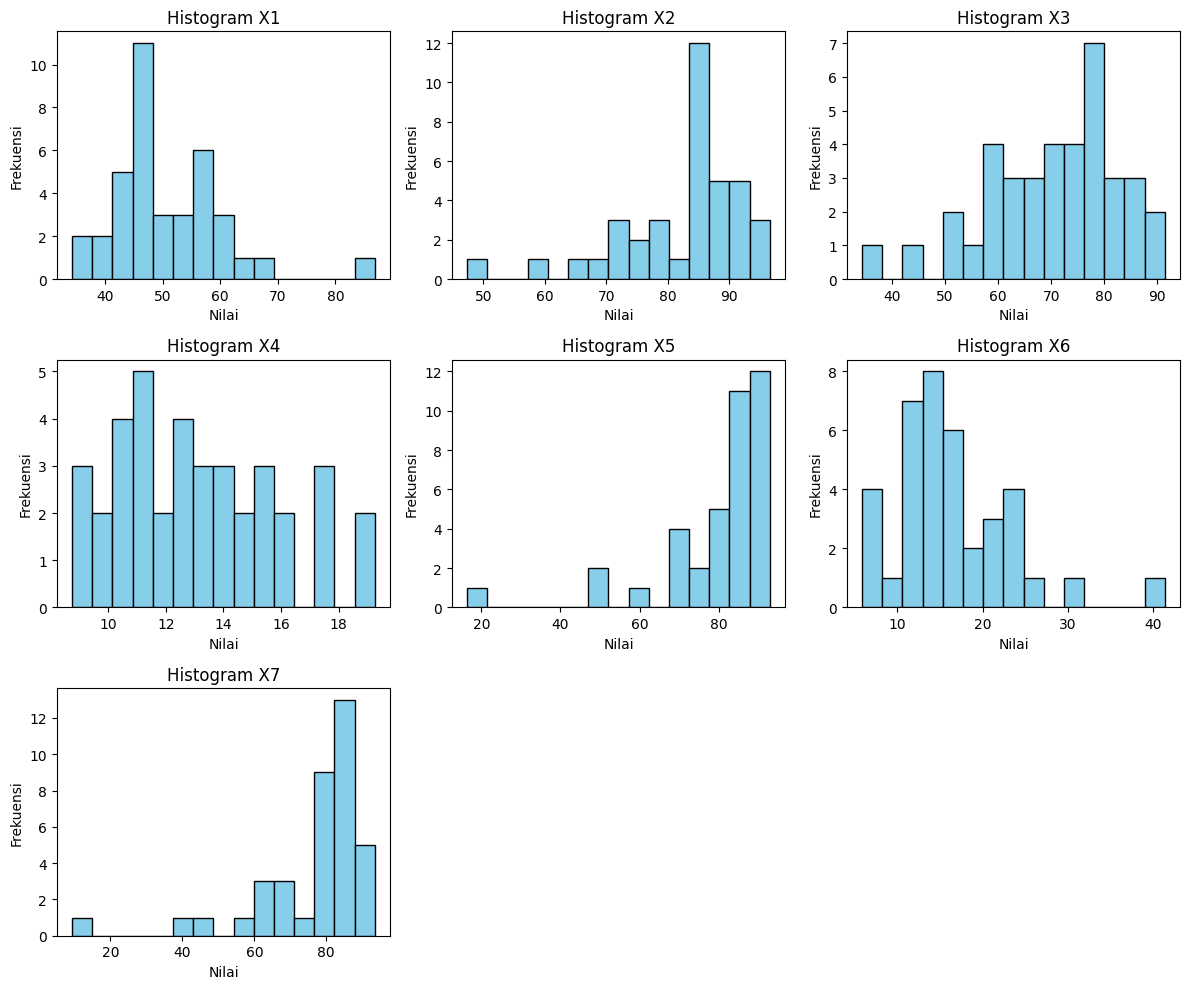

In [36]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    plt.hist(df[col], bins=15, edgecolor='black', color='skyblue')
    plt.xlabel('Nilai')
    plt.ylabel('Frekuensi')
    plt.title(f'Histogram {col}')
plt.tight_layout()
plt.show()

TAHAP 7: Normalisasi Data

In [37]:
data = df[features].copy()

scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)
data_normalized = pd.DataFrame(data_normalized, columns=features)

print("Data berhasil dinormalisasi (rentang 0-1)")
data_normalized.head(40)

Data berhasil dinormalisasi (rentang 0-1)


,X1,X2,X3,X4,X5,X6,X7
0,0.213301,0.759386,0.640527,0.023810,0.731695,0.159955,0.694108
1,0.361000,0.746365,0.681991,0.523810,0.894482,0.221628,0.846044
2,0.296254,0.775548,0.803538,0.333333,0.963520,0.400451,0.918152
3,0.440245,0.786492,0.754061,0.404762,0.911872,0.234300,0.853291
4,0.235168,0.782236,0.673541,0.309524,0.892521,0.221909,0.867902
5,0.320688,0.788418,0.776129,0.523810,0.878138,0.269502,0.848776
6,0.145560,0.800527,0.773151,0.190476,0.929524,0.308927,0.898907
7,0.262502,0.870446,0.715312,0.523810,0.950837,0.316249,0.917439
8,0.469528,0.753154,0.903236,0.690476,0.990847,0.375387,0.966382
9,0.654830,0.816081,0.850081,0.642857,0.955413,0.500141,0.956997


TAHAP 8: Penentuan Jumlah Cluster Optimal

Metode Elbow

k = 2: WCSS = 6.74
k = 3: WCSS = 4.38
k = 4: WCSS = 2.98
k = 5: WCSS = 2.39
k = 6: WCSS = 1.95
k = 7: WCSS = 1.70
k = 8: WCSS = 1.49
k = 9: WCSS = 1.28
k = 10: WCSS = 1.12


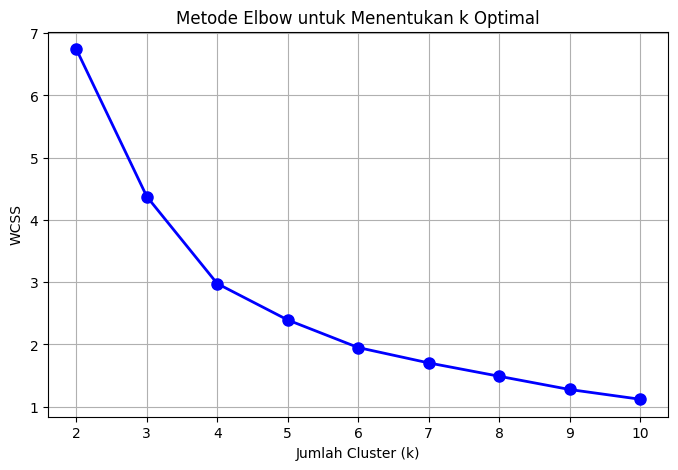

In [38]:
wcss = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_normalized)
    wcss.append(kmeans.inertia_)
    print(f"k = {k}: WCSS = {kmeans.inertia_:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS')
plt.title('Metode Elbow untuk Menentukan k Optimal')
plt.grid(True)
plt.show()

Metode Silhouette Coefficient

k = 2: Silhouette = 0.3702
k = 3: Silhouette = 0.3687
k = 4: Silhouette = 0.3703
k = 5: Silhouette = 0.3046
k = 6: Silhouette = 0.2935
k = 7: Silhouette = 0.2721
k = 8: Silhouette = 0.2729
k = 9: Silhouette = 0.2641
k = 10: Silhouette = 0.2342


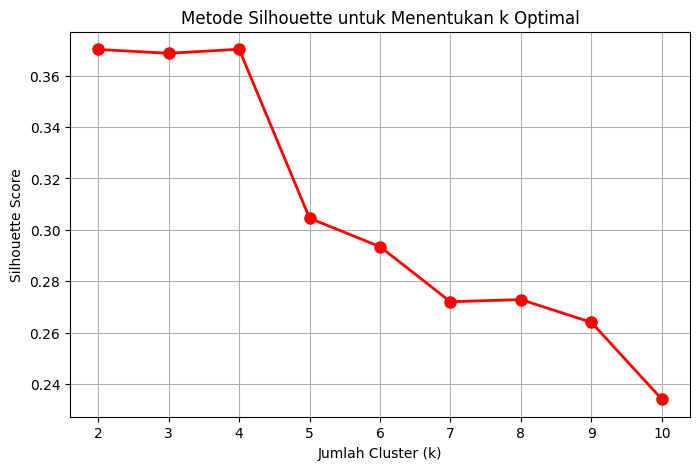


Jumlah cluster optimal: k = 3


In [39]:
silhouette_scores = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data_normalized)
    sil = silhouette_score(data_normalized, labels)
    silhouette_scores.append(sil)
    print(f"k = {k}: Silhouette = {sil:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Metode Silhouette untuk Menentukan k Optimal')
plt.grid(True)
plt.show()

optimal_k = 3
print(f"\nJumlah cluster optimal: k = {optimal_k}")

TAHAP 9: Implementasi Algoritma K-Means Clustering

In [40]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(data_normalized)

print(f"Clustering selesai dengan {optimal_k} cluster")
print("\nDistribusi anggota per cluster:")
print(df['Cluster'].value_counts().sort_index())

Clustering selesai dengan 3 cluster

Distribusi anggota per cluster:
Cluster
0    10
1     9
2    19
Name: count, dtype: int64


TAHAP 10: Evaluasi Kualitas Cluster

In [41]:
dbi_score = davies_bouldin_score(data_normalized, df['Cluster'])
sil_score = silhouette_score(data_normalized, df['Cluster'])

print("\n=== Evaluasi Kualitas Cluster ===")
print(f"Davies-Bouldin Index: {dbi_score:.4f} (semakin mendekati 0 semakin baik)")
print(f"Silhouette Score: {sil_score:.4f} (>0.5 = baik, >0.7 = sangat baik)")


=== Evaluasi Kualitas Cluster ===
Davies-Bouldin Index: 0.9195 (semakin mendekati 0 semakin baik)
Silhouette Score: 0.3687 (>0.5 = baik, >0.7 = sangat baik)


TAHAP 11: Analisis Karakteristik Cluster

Anggota Provinsi per Cluster

In [42]:
print("\n=== Anggota Provinsi per Cluster ===")
for cluster in range(optimal_k):
    anggota = df[df['Cluster'] == cluster]['Provinsi'].tolist()
    print(f"\nCluster {cluster} ({len(anggota)} provinsi):")
    print(', '.join(anggota))


=== Anggota Provinsi per Cluster ===

Cluster 0 (10 provinsi):
 Kep. Bangka Belitung,  Kepulauan Riau,  DKI Jakarta,  Jawa Barat,  Jawa Tengah,  DI Yogyakarta,  Jawa Timur,  Banten,  Bali,  Kalimantan Timur

Cluster 1 (9 provinsi):
 Nusa Tenggara Timur,  Maluku,  Maluku Utara,  Papua Barat,  Papua Barat Daya,  Papua,  Papua Selatan,  Papua Tengah,  Papua Pegunungan

Cluster 2 (19 provinsi):
 Aceh,  Sumatera Utara,  Sumatera Barat,  Riau,  Jambi, Sumatera Selatan,  Bengkulu,  Lampung,  Nusa Tenggara Barat,  Kalimantan Barat,  Kalimantan Tengah,  Kalimantan Selatan,  Kalimantan Utara,  Sulawesi Utara,  Sulawesi Tengah,  Sulawesi Selatan,  Sulawesi Tenggara,  Gorontalo,  Sulawesi Barat


Profil Rata-rata per Cluster

In [43]:
cluster_profiles = df.groupby('Cluster')[features].mean()
print("\n=== Profil Rata-rata per Cluster ===")
print(cluster_profiles.round(2))


=== Profil Rata-rata per Cluster ===
            X1     X2     X3     X4     X5     X6     X7
Cluster                                                 
0        62.30  91.00  82.75  16.62  89.32  25.27  88.55
1        41.67  68.67  53.72  11.94  59.89  10.05  53.14
2        49.10  84.36  71.11  11.80  84.62  14.68  81.56


TAHAP 12: Visualisasi Hasil

Radar Plot

In [44]:
categories = features
fig = go.Figure()

for cluster in range(optimal_k):
    fig.add_trace(go.Scatterpolar(
        r=cluster_profiles.loc[cluster].values,
        theta=categories,
        fill='toself',
        name=f'Cluster {cluster}'
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
    title=f'Profil Cluster Pendidikan Digital dan Fasilitas Sekolah (k={optimal_k})',
    showlegend=True
)
fig.show()

Scatter Plot PCA

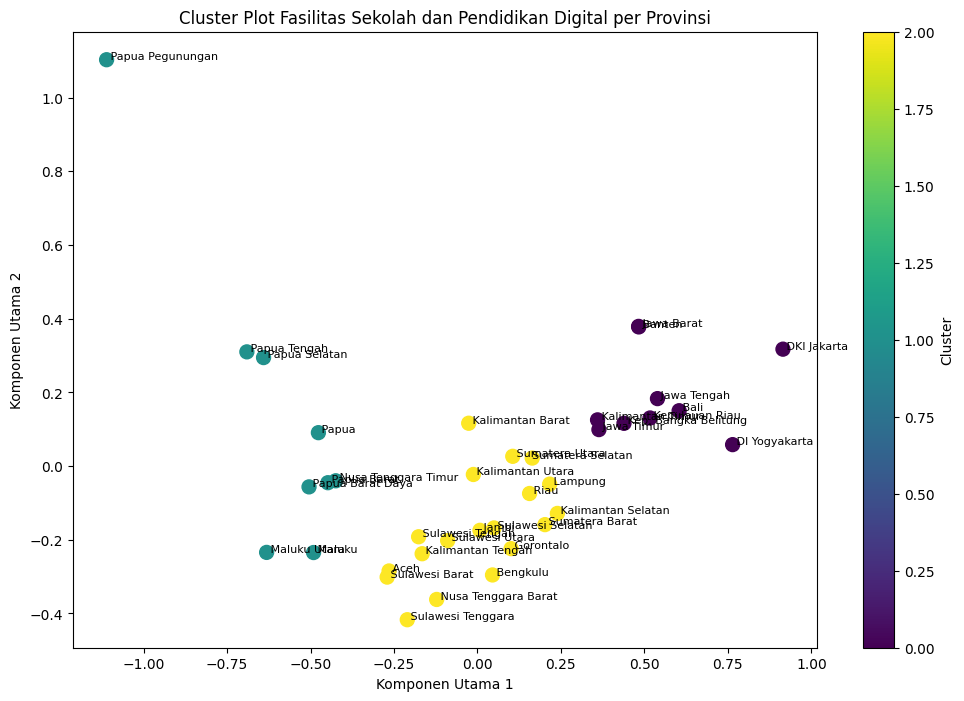

In [45]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(data_normalized)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(principal_components[:, 0], principal_components[:, 1],
                      c=df['Cluster'], cmap='viridis', s=100)
plt.xlabel('Komponen Utama 1')
plt.ylabel('Komponen Utama 2')
plt.title('Cluster Plot Fasilitas Sekolah dan Pendidikan Digital per Provinsi')
plt.colorbar(scatter, label='Cluster')
for i, provinsi in enumerate(df['Provinsi']):
    plt.annotate(provinsi, (principal_components[i, 0], principal_components[i, 1]), fontsize=8)
plt.show()